In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv('canteen_rush_1000.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print(df.head())

        Date  Time  Day  Lunch_Time Weather  Students Rush_Level
0 2026-03-11    14  Wed           0  Cloudy        21        Low
1 2026-03-24    14  Tue           0  Cloudy        20        Low
2 2026-03-01    12  Sun           1  Cloudy        85       High
3 2026-02-15    12  Sun           1  Cloudy        94       High
4 2026-03-15    13  Sun           1   Rainy        50     Medium


In [77]:
df.isnull()
df.isnull().sum()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1000 non-null   datetime64[ns]
 1   Time        1000 non-null   int64         
 2   Day         1000 non-null   object        
 3   Lunch_Time  1000 non-null   int64         
 4   Weather     1000 non-null   object        
 5   Students    1000 non-null   int64         
 6   Rush_Level  1000 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 54.8+ KB


,Date,Time,Lunch_Time,Students
count,1000,1000.000000,1000.000000,1000.000000
mean,2026-03-02 13:58:04.800000256,10.999000,0.411000,39.373000
min,2026-02-01 00:00:00,8.000000,0.000000,10.000000
25%,2026-02-16 00:00:00,9.000000,0.000000,18.000000
50%,2026-03-03 00:00:00,11.000000,0.000000,26.000000
75%,2026-03-17 00:00:00,13.000000,1.000000,61.000000
max,2026-03-31 00:00:00,14.000000,1.000000,99.000000
std,NaN,2.031533,0.492261,26.721226


<h3 style="color:skyblue">Target Distribution</h3>

In [78]:
df['Rush_Level'].value_counts()

Rush_Level
Low       599
Medium    208
High      193
Name: count, dtype: int64

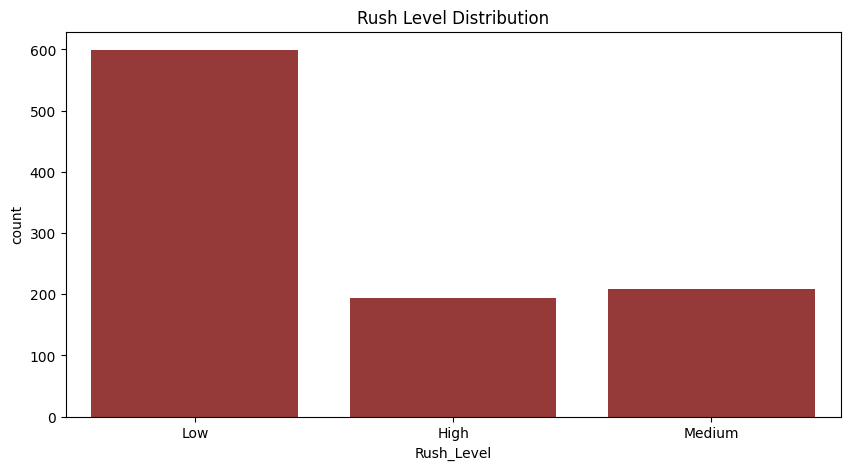

In [79]:
plt.figure(figsize=(10,5))
sns.countplot(x='Rush_Level', data=df,color='brown')
plt.title("Rush Level Distribution")
plt.show()

<h3 style="color:skyblue">Students vs Rush_Level</h3>

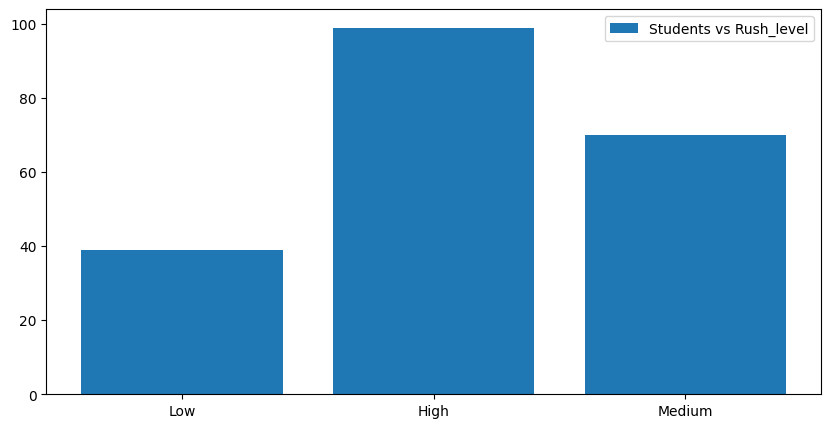

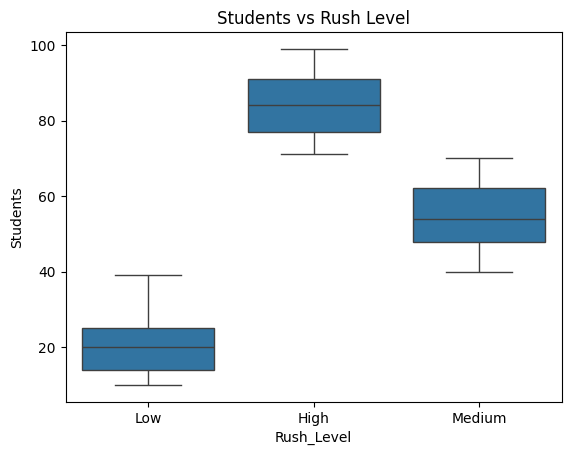

In [80]:
plt.figure(figsize=(10,5))
plt.bar( df['Rush_Level'],
        df['Students'],
        label='Students vs Rush_level')
plt.legend()
plt.show()

sns.boxplot(x='Rush_Level', y='Students', data=df)
plt.title("Students vs Rush Level")
plt.show()

<h3 style="color:skyblue">Time vs Rush_Level</h3>

In [81]:
df['Time'].value_counts()

Time
13    149
10    149
8     148
14    147
9     145
12    143
11    119
Name: count, dtype: int64

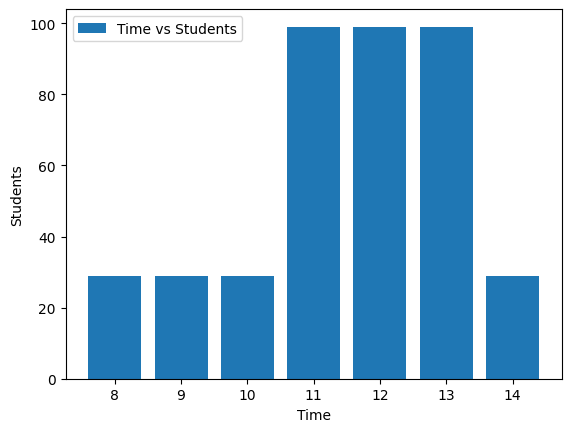

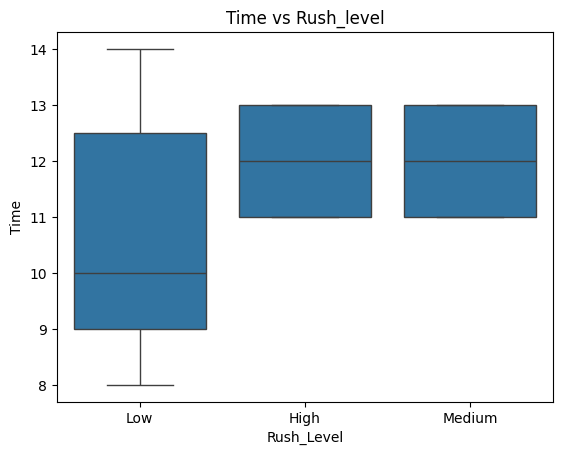

In [82]:
plt.bar(df['Time'],df['Students'],label = 'Time vs Students')
plt.xlabel('Time')
plt.ylabel('Students')
plt.legend()
plt.show()

sns.boxplot(x='Rush_Level',
            y='Time',
            data=df)
plt.title("Time vs Rush_level")
plt.show()

<h3 style="color:skyblue">Lunch_Time vs Rush_Level</h3>

In [83]:
df['Lunch_Time'].value_counts()

Lunch_Time
0    589
1    411
Name: count, dtype: int64

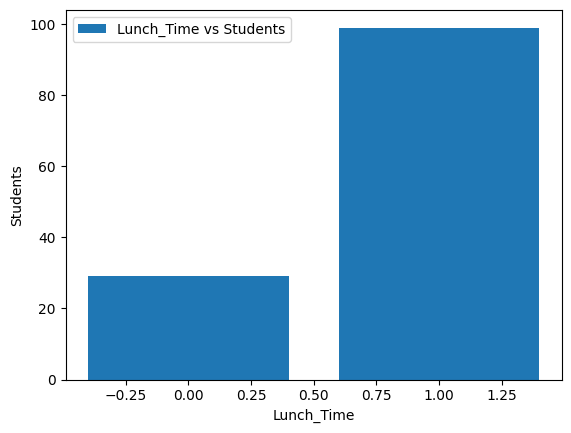

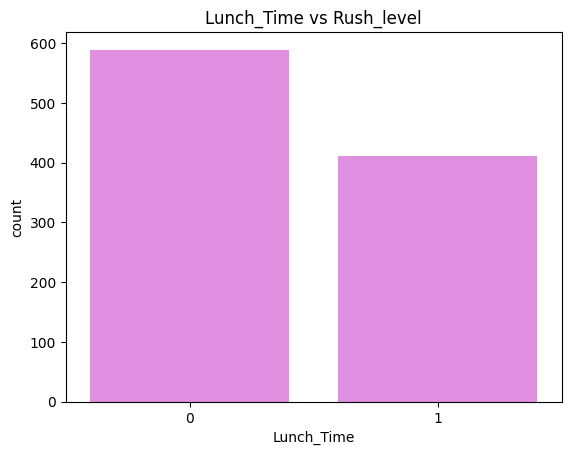

In [84]:
plt.bar(df['Lunch_Time'],df['Students'],label='Lunch_Time vs Students')
plt.xlabel('Lunch_Time')
plt.ylabel('Students')
plt.legend()
plt.show()

sns.countplot(x='Lunch_Time',
            data=df,
            color='violet')
plt.title("Lunch_Time vs Rush_level")
plt.show()

<h3 style="color:skyblue">Weather vs Rush_Level</h3>

In [85]:
df['Weather'].value_counts()

Weather
Sunny     578
Rainy     225
Cloudy    197
Name: count, dtype: int64

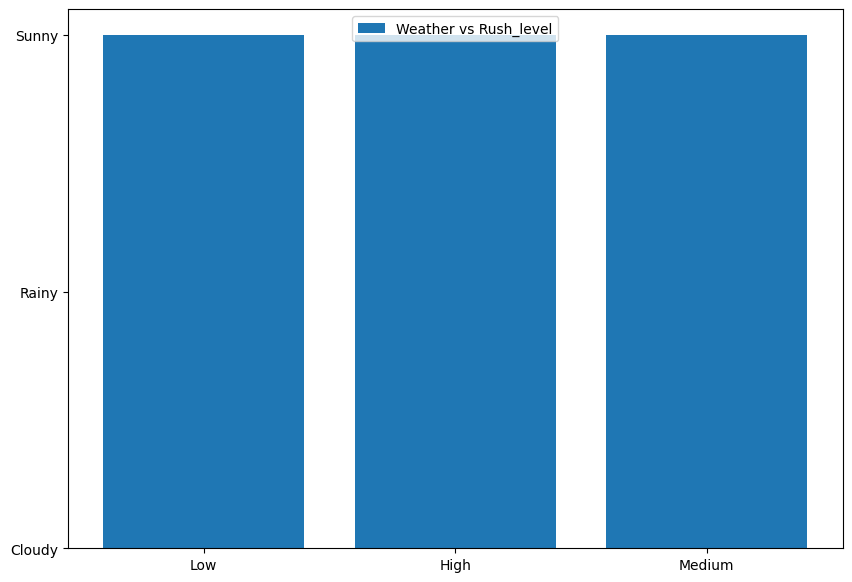

C:\Users\wasim\AppData\Local\Temp\ipykernel_42052\3789484615.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:yellow'` for the same effect.

  sns.countplot(x='Weather',


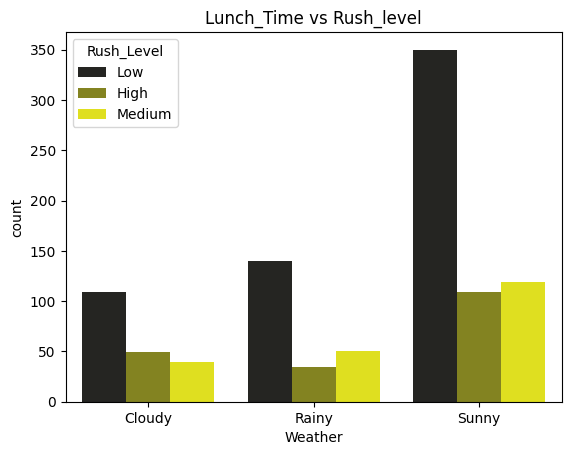

In [86]:
plt.figure(figsize=(10,7))
plt.bar(
        df['Rush_Level'],
        df['Weather'],
        label='Weather vs Rush_level')
plt.legend()
plt.show()

sns.countplot(x='Weather',
              hue='Rush_Level',
            data=df,
            color='yellow')
plt.title("Lunch_Time vs Rush_level")
plt.show()

<h3 style="color:skyblue">Day vs Rush_Level</h3>

In [87]:
df['Day'].value_counts()

Day
Mon    171
Thu    156
Tue    142
Sat    141
Sun    140
Wed    135
Fri    115
Name: count, dtype: int64

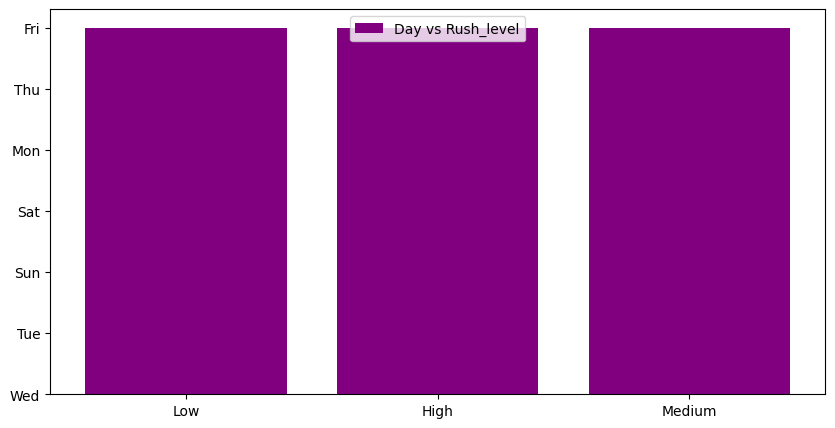

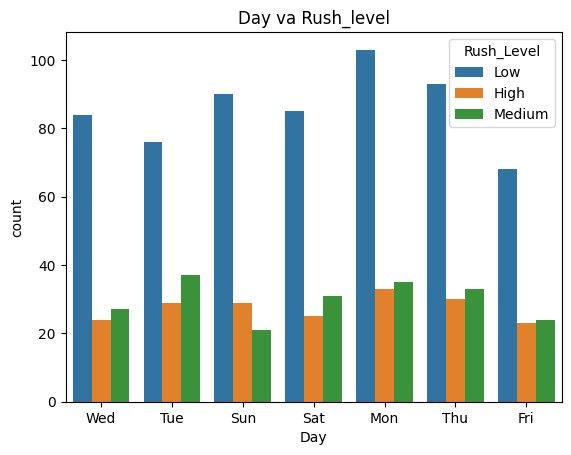

In [88]:
plt.figure(figsize=(10,5))
plt.bar(df['Rush_Level'],
        df['Day'],
        color='purple',
        label='Day vs Rush_level')
plt.legend()
plt.show()

sns.countplot(x = 'Day',
              hue='Rush_Level',
              data=df)
plt.title("Day va Rush_level")
plt.show()

<h3 style="color:skyblue">Month vs Rush_Level</h3>

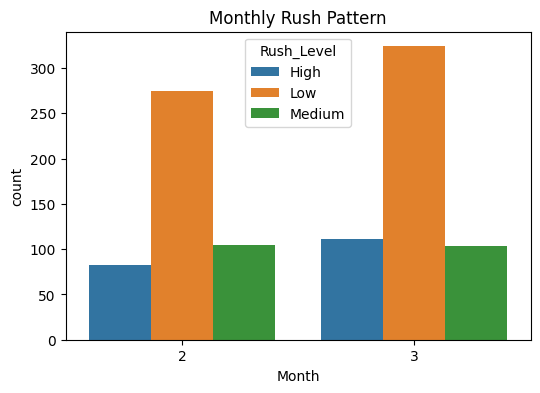

In [89]:
df['Month'] = df['Date'].dt.month

plt.figure(figsize=(6,4))
sns.countplot(x='Month', hue='Rush_Level', data=df)
plt.title("Monthly Rush Pattern")
plt.show()

In [91]:
# 📊 What is Correlation?

# Correlation means:

# 🔗 “How strongly two variables are related”

# It tells:

# If one increases, does the other increase?

# If one increases, does the other decrease?

# Or are they unrelated?

# 📈 Correlation Values Range

# Correlation value is between -1 and +1

# Value	Meaning
# +1	Perfect positive relationship
# 0	No relationship
# -1	Perfect negative relationship
# 🔵 Positive Correlation (+)

# If Students increase → Rush increases

# Example:

# Students ↑  →  Rush ↑
# 🔴 Negative Correlation (-)

# If Students increase → Rush decreases

# Example:

# Students ↑  →  Rush ↓
# ⚪ Zero Correlation

# No relationship.

# 🧊 What is a Heatmap?

# A Heatmap is just a colored table.

# Dark red = Strong positive

# Dark blue = Strong negative

# Light color = Weak relation

# 🔎 How to Read It (Very Important)

# Imagine you see this:

# 	Students	Lunch_Time	Rush
# Students	1.00	0.10	0.85
# Lunch_Time	0.10	1.00	0.65
# Rush	0.85	0.65	1.00

# Now understand:

# 🟢 Students vs Rush = 0.85

# ✔ Strong positive relationship
# ✔ More students → Higher rush

# This is very important feature 🔥

# 🟡 Lunch_Time vs Rush = 0.65

# ✔ Moderate positive relationship
# ✔ During lunch → Rush increases

# ⚪ Time vs Rush = 0.05

# ✖ Very weak
# ✖ Time alone may not matter much

# 🧠 Why Diagonal Is Always 1?

# Because:

# Students vs Students = 100% related

# Time vs Time = 100% related

# So always 1.

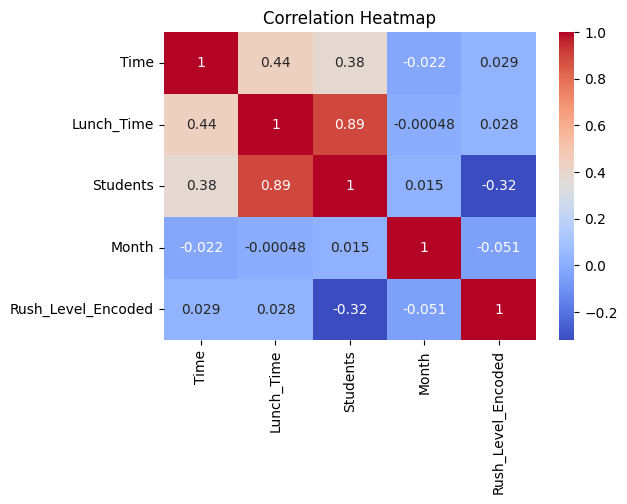

In [90]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode only target
df['Rush_Level_Encoded'] = le.fit_transform(df['Rush_Level'])

# Select ONLY numeric columns
numeric_df = df[['Time',
                 'Lunch_Time',
                 'Students',
                 'Month',
                 'Rush_Level_Encoded']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()